## Authors: Vu-Minh D. Hoang and Christopher Won

# Theoretical Mathematics

The references for the project are the following:


Laub, Patrick J., Lee, Young, and Taimre, Thomas (2021). The elements of Hawkes processes.

Patrick J. Laub, Young Lee, Philip K. Pollett, Thomas Taimre, Hawkes models and their applications, Annu. Rev. Stat. Appl. 12 (2024).

Laub, P. (2014), “Hawkes Processes: Simulation, Estimation, and Validation,” Bachelor’s Thesis,
University of Queensland

Note: All the definitions in the references above are stated in this notebook and the proofs were done by us.

### Basic definitions of intensity process

---

**Definition 1.** A collection $(T_n )_{n∈\mathbb{N}}$ of $\mathbb{R}_+$ -valued random variables is called
a Point process if, almost surely,
$$
T_0 = 0,\quad
∀n ∈ N,
T_n < T_{n+1} , \quad
and \quad
\lim_{n\to \infty}T_n = +\infty.
$$


**Definition 2.** A stochastic process $N (t)$, defined for $t \ge 0$, is a counting process starting
at $N (0) = 0$ if $N (t)$ only takes values in $\{0, 1, 2, . . . \}$ and increases in jumps of size $+1$, where
$$
N(t) = \sum_{n=1}^∞ \mathbf{1}_{\{ T_n \le t \} }
$$
We note that $N (t)$ is right-continous with left-limits.

---

---
Let
 - $\mathcal{F}_t = \sigma(\{N(s) : s \leq t\})$ - includes information up to $t$
-  $\mathcal{F}_{t^-} = \sigma(\{N(s) : s < t\})$ - information strictly before $t$


We also observe that
$$\mathcal{F}_t = \mathcal{F}_{t^-} \vee \sigma(\Delta N(t))$$

where we denote the jump of $N$ at time $t$ is $\Delta N(t) = N(t) - N(t^-) = \lim_{h \downarrow 0} [N(t)-
N(t-h)]$. We note that almost surely, $\Delta N(t) = 1$ if there is jump at time $t$ and $0$ if there's no jump at time $t$.

Since $h>0$, we have $t-h<t$, which means every
$s$ satisfying $s \leq t-h<t$. Therefore:
$$\mathcal{F}_{t-h} = \sigma(\{N(s) : s \leq t-h\}) \subseteq \sigma(\{N(s) : s < t\}) = \mathcal{F}_{t^-}$$

---

**Definition 3 (Conditional intensity)**. Let  $(N(t) : t \geq 0)$ a counting process. The conditional intensity process of $N(t)$ is defined, for $t \ge 0$, by
$$
\lambda^*(t) := \lambda(t
\mid  \mathcal{F}_{t^-} )  = \lim_{h\downarrow 0} \frac{\mathbb{E}[N(t+h) - N(t) \mid \mathcal{F}_{t^-}  ]}{h}
$$
$\lambda^*(t)  $ must be chosen to
avoid explosion, where we use the standard definition of explosion as the event that $N (t) - N (s) = \infty$
for $t - s < \infty$. In particular, we assume $\lambda^*$ is locally bounded.

**Definition 4 (Compensator).** For a counting process $N(\cdot )$ the non-decreasing
function
$$
\Lambda(t) = \int_0^t \lambda^*(s) ds
$$
is called the compensator of the counting process.

Technically $\Lambda(t)$ is the unique $\mathcal{F}_{t}$ predictable function, with
$\Lambda(0) = 0$ and is non-decreasing, such that $N(t) = M(t) + \Lambda(t)$ almost surely for
$t \ge 0$ and where $M(t)$ is an $\mathcal{F}_t$ (local) martingale, whose existence is guaranteed
by the Doob–Meyer decomposition theorem.


---


---
**Remark 1**

One way to characterise a particular point process is to specify the distribution function of the next arrival time conditional on the past. Given the history up until the last arrival $t_k$, $\mathcal{F}(t_k)$, the conditional c.d.f. (and p.d.f.) of the next arrival time $T_{k+1}$ are defined as
$$
F^*(t \mid \mathcal{F}(t_k)) = \mathbb{P}(T_{k+1} \le t \mid  \mathcal{F}(t_k)) = \int_{t_k}^t f^*(s \mid \mathcal{F}(t_k)) \, \mathrm{d}s.
$$
The joint p.d.f. for a realisation $\{t_1, t_2, \dots, t_k\}$ is then, by the chain rule,
\begin{equation}
f(t_1, t_2, \dots, t_k) = \prod_{i=1}^k f^*(t_i \mid \mathcal{F}(t_{i-1})).
\end{equation}
where $t_0 = 0$ and $\mathcal{F}(t_0) = \{\emptyset, \Omega \}.$

An alternative way to define the conditonal intensity is via the conditional hazard rate relation:
$$
\lambda^*(t) = \frac{f^*(t \mid \mathcal{F}(t_k)) }{ 1 - F^*(t \mid \mathcal{F}(t_k)) }
$$

---

Furthermore, we show by simple calculation that:

Since $f^*(t \mid \mathcal{F}(t_k)) = \frac{d}{dt} F^*(t \mid \mathcal{F}(t_k))$, the right-hand side is:
$$
\lambda^*(t) = \frac{\frac{d}{dt} F^*(t \mid \mathcal{F}(t_k))}{1 - F^*(t \mid \mathcal{F}(t_k))} = -\frac{d}{dt} \log(1 - F^*(t \mid \mathcal{F}(t_k)))
$$
Integrating both sides from $t_k$ to $t$ yields
$$
\int_{t_k}^{t} \lambda^*(v) \, dv = -\log(1 - F^*(t \mid \mathcal{F}(t_k))) + \log(1 - F^*(t_k \mid \mathcal{F}(t_k)))
$$

Now $F^*(t_k \mid \mathcal{F}(t_k)) = \mathbb{P}(T_{k+1} \le t_k \mid \mathcal{F}(t_k)) = 0$, since the next arrival $T_{k+1}$ must come after $t_k$. So $\log(1 - 0) = 0$, giving:
$$
\int_{t_k}^{t} \lambda^*(v) \, dv = -\log(1 - F^*(t \mid \mathcal{F}(t_k)))
$$
Exponentiating both terms get:
$$
1 - F^*(t \mid \mathcal{F}(t_k)) = \exp\left(-\int_{t_k}^t \lambda^*(v) \, dv\right)
$$
which yields both:
$$
F^*(t \mid \mathcal{F}(t_k)) = 1 - \exp\left(-\int_{t_k}^t \lambda^*(v) \, dv\right)
$$
and
$$
f^*(t \mid \mathcal{F}(t_k)) = \lambda^*(t) \cdot \exp\left(-\int_{t_k}^t \lambda^*(v) \, dv\right)
$$

---

### Properties of counting process

---

**Proposition 1.** Let $N(t)$ be a simple counting process with conditional intensity $\lambda^*(t)$ relative to the filtration $\{\mathcal{F}_t\}_{t \geq 0}$. Then for any $t \geq 0$,
$$
\mathbb{P}\big(\Delta N(t) = 1 \mid \mathcal{F}_{t-}\big) = 0 \quad \text{almost surely}.
$$
Furthermore, we can conclude that $\mathbb{P}(\Delta N(t)=0) =1$.

---

*Proof.*  Let $A \in \mathcal{F}_{t-}$,
since  $ N(t)-N(t-h)$ is non-negative (counting process is non-decreasing)
   and
   $ N(t)-N(t-h)$ is decreasing to $\Delta N(t)$
as $h$
 decreases, so by the Monotone Convergence Theorem
$$
\mathbb{E}\big[\mathbf{1}_A \Delta N(t)\big] = \lim_{h \downarrow 0} \mathbb{E}\Big[\mathbf{1}_A \big(N(t) - N(t-h)\big)\Big]
$$

Using the martingale decomposition $N(t) - N(t-h) = \big(M(t) - M(t-h)\big) + \int_{t-h}^t \lambda^*(s) \, ds$ and the constant expectation of martingale implies
$$
\mathbb{E}\big[N(t) - N(t-h)\big] = \mathbb{E}[M(t) - M(t-h)]+ \mathbb{E}\left[\int_{t-h}^t \lambda^*(s) \, ds\right] = \mathbb{E}\left[\int_{t-h}^t \lambda^*(s) \, ds\right]
$$
By local boundedness of $\lambda^*$, there exists $C < \infty$ and $\epsilon > 0$ such that $\lambda^*(s) \leq C$ for all $s \in [t-\epsilon, t]$. For $0 < h < \epsilon$, we have
$$
0 \leq \mathbb{E}\left[\int_{t-h}^t \lambda^*(s) \, ds\right] \leq \int_{t-h}^t C \, ds = C \cdot h.
$$


Since $0 \leq \mathbf{1}_A \leq 1$ and $N(t) - N(t-h) \geq 0$, we obtain the bound
$$
0 \leq \mathbb{E}\Big[\mathbf{1}_A \big(N(t) - N(t-h)\big)\Big] \leq \mathbb{E}\big[N(t) - N(t-h)\big]\leq  C \cdot h.
$$

Taking the limit as $h \downarrow 0$ and applying the squeeze theorem gives $\mathbb{E}\big[\mathbf{1}_A \Delta N(t)\big] = 0$.

We've shown that for every $A \in \mathcal{F}_{t-}:
\mathbb{E}[\mathbf{1}_A \Delta N(t)] = 0.$
By the defining property of conditional expectation, $\mathbb{E}[\Delta N(t) \mid \mathcal{F}_{t-}]$ is the unique $\mathcal{F}_{t-}$-measurable random variable $Z$ such that:
\begin{equation}
\mathbb{E}[\mathbf{1}_A \Delta N(t)] = \mathbb{E}[\mathbf{1}_A Z] \quad \text{for all } A \in \mathcal{F}_{t-}
\end{equation}
Since $\mathbb{E}[\mathbf{1}_A \Delta N(t)] = 0$ for all $A$, we must have $Z = 0$ almost surely. Therefore:
\begin{equation}
\mathbb{E}[\Delta N(t) \mid \mathcal{F}_{t-}] = 0 \quad \text{a.s.}
\end{equation}
Finally, since $\Delta N(t) \in \{0, 1\}$ for a simple counting process, the conditional expectation coincides with the conditional probability:
$$
\mathbb{P}\big(\Delta N(t) = 1 \mid \mathcal{F}_{t-}\big) = \mathbb{E}\big[\Delta N(t) \mid \mathcal{F}_{t-}\big] = 0 \quad \text{a.s.}
$$

$\square$

---

---

**Proposition 2.** For all $m \in \mathbb{N}$, we have $\mathbb{P}(N(t+h) - N(t) = m \mid \mathcal{F}_{t^-}) = \mathbb{P}(N(t+h) - N(t) = m \mid \mathcal{F}_{t})$ a.s

---
*Proof.*
Since $\mathcal{F}_t = \mathcal{F}_{t^-} \vee \sigma(\Delta N(t))$, conditioning on $\mathcal{F}_t$ is equivalent to conditioning on both $\mathcal{F}_{t^-}$ and $\Delta N(t)$ simultaneously. Since $\Delta N(t) \in \{0,1\}$, by the conditional expectation property:
\begin{align*}
\mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_t) &= \mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_{t^-}, \Delta N(t)=0) \cdot \mathbf{1}_{\{\Delta N(t)=0\}} \\
&\quad + \mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_{t^-}, \Delta N(t)=1) \cdot \mathbf{1}_{\{\Delta N(t)=1\}}
\end{align*}
From Proposition 1, we have $\mathbb{P}(\Delta N(t)=1 \mid \mathcal{F}_{t^-})=0$ a.s., and taking unconditional expectations gives $\mathbb{P}(\Delta N(t)=1)=0$. Therefore almost surely $\mathbf{1}_{\{\Delta N(t)=0\}}=1$ and $\mathbf{1}_{\{\Delta N(t)=1\}}=0$, so the above reduces to:
\begin{align*}
\mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_t) &= \mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_{t^-}, \Delta N(t)=0) \quad \text{a.s.}
\end{align*}
Applying the law of total probability, now conditioning on $\mathcal{F}_{t^-}$, and using $\mathbb{P}(\Delta N(t)=0 \mid \mathcal{F}_{t^-})=1$ and $\mathbb{P}(\Delta N(t)=1 \mid \mathcal{F}_{t^-})=0$ almost surely:
\begin{align*}
\mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_{t^-}) &= \mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_{t^-}, \Delta N(t)=0) \cdot \mathbb{P}(\Delta N(t)=0 \mid \mathcal{F}_{t^-}) \\
&\quad + \mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_{t^-}, \Delta N(t)=1) \cdot \mathbb{P}(\Delta N(t)=1 \mid \mathcal{F}_{t^-})\\
&= \mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_{t^-}, \Delta N(t)=0) \quad \text{a.s.}
\end{align*}
Since both $\mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_t)$ and $\mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_{t^-})$ equal $\mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_{t^-}, \Delta N(t)=0)$ almost surely, we conclude:
$$
\mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_t) = \mathbb{P}(N(t+h)-N(t)=m \mid \mathcal{F}_{t^-}) \quad \text{a.s.}
$$

$\square$

---

### Hawkes Process

---

**Definition 5.** Consider $(N(t) : t \geq 0)$ a counting process,
with associated history $(\mathcal{F}_{t^-} : t \geq 0)$, we have that it satisfies
$$\mathbb{P}(N(t+h) - N(t) = m \mid \mathcal{F}_{t^-}) =
\begin{cases}
1 - \lambda^*(t)\, h + o(h), & m = 0 \\
\lambda^*(t)\, h + o(h), & m = 1 \\
o(h), & m > 1
\end{cases}$$
We note that if $\lambda^*(t)$ is a constant then it reduces to a standard Poisson Process with independent increments.

**Collorary:** A consequence of Proposition 2 is that Definiton 5 can also be changed to $\mathbb{P}(N(t+h)-N(t)=m\mid\mathcal{F}_t)$, and Definiton 3 (Conditional density) can be replaced to the following
\begin{align*}
    \mathbb{E}[N(t+h) - N(t) \mid \mathcal{F}_{t^-}  ] &= \sum_{m=0}^\infty m\cdot \mathbb{P}(N(t+h) - N(t) = m \mid \mathcal{F}_{t^-})\\& = \sum_{m=0}^\infty m\cdot  \mathbb{P}(N(t+h) - N(t) = m \mid \mathcal{F}_{t}) \\&=\mathbb{E}[N(t+h) - N(t) \mid \mathcal{F}_{t}  ] \quad \text{a.s.}
\end{align*}
This is often why in the literature, people often use them interchangably.





---

---

**Definition 6 (Stochastic integral with respect to $N$)**. For all measurable function $H$, we define
$$
\int_{(0,t]} H(u) dN(u) = \sum_{0 < u \le t} H(u) \Delta N(u) = \sum_{0<T_i \le t} H(T_i)
$$
since $\Delta N(u) = 1$ at jump times $T_1, T_2,\ldots$ and $0$ otherwise. Note that including time $0$ would not change the integral because we assume $\Delta N(0) = 0$ a.s.

**Definition 7 (Hawkes Process)** Consider a counting process $N(t)$ that satisfies Definition 5. Using $\{t_1, t_2, \ldots, \}$ to
denote the observed sequence of past arrival times of the point process. The Hawkes process’ conditional intensity function is supposed to be of the form
$$
\lambda^*(t) = \mu + \int_{(0,t) } \phi(t-u) d N(u) = \mu  +  \sum_{t_i < t} \phi(t-t_i)
$$
for some $\mu  > 0$ and $\phi : (0, \infty) \to [0, \infty)$ which are called the background intensity
and excitation function, respectively. Assume that $\phi(\cdot) \ne  0$ to avoid the trivial
case, that is, a homogeneous Poisson process with intensity $\mu.$ We note that  strict upper limit is essential — it ensures $\lambda^*(t)
$ is $\mathcal{F}_{t^-}
$​-measurable (predictable).


In the case of **exponential kernel**, $\phi(t) =
\alpha e^{-\beta t}$ , for constants $\alpha, \beta > 0, $ then
$$
\lambda^*(t) = \mu  + \int_{(0,t) } \alpha e^{-\beta (t-s)} d N(s) = \mu  +  \sum_{t_i < t} \alpha e^{-\beta (t-t_i)}
$$

It is required that the ratio $\int_0^\infty \phi(t)dt = \alpha/\beta < 1$ to avoid explosion. Furthermore, we notice that setting $\alpha = 0$ gives the standard Poisson Process. In addition, $\lambda^*$ is left-continuous with right limits, where the right limit is $$ \lambda^*(t^+) = \lim_{s↓ t}\lambda^*(t) = \lambda^*(t) + \alpha\Delta N(t) =\begin{cases}
\lambda^*(t), & \text{if $t$ is not a jump time}\\
\lambda^*(t) + \alpha , & \text{if $t$ is a jump time}
\end{cases}$$

---


---

Define the shifted counting process:
$$\tilde{N}(v) = N(t+v) - N(t), \quad v \geq 0
$$
 counting only the events that occur strictly after time $t$, ignoring everything before $t$.
If the original process $N$ has jump times $T_1,T_2,T_3,\ldots$, then the jump times of the shifted process $\tilde{N}$ are exactly:
$\tilde{T}_i :=T_i-t$ for all $i$ such that $T_i>t$.

By change of variable, $T_i \in (t,t+u)$ if and only if $\tilde{T}_i\in (0,u)$.

 \begin{align*}
     \int_{(t,t+u)} H(s) dN(s) =  \sum_{t<T_i < t+u} H(T_i) =
     \sum_{0<\tilde{T}_i < u} H(\tilde{T}_i +t) = \int_{(0,u)} H(v+t)d \tilde{N}(v)
 \end{align*}

 ---

---

**Lemma 1.** Let $\tilde{T}_1 < \tilde{T}_2 < \cdots$ be the jump times of $\tilde{N}$ and conditional intensity $\tilde{\lambda}^*(v)$ relative to the counting process $\tilde{N}$ under the filtration $\mathcal{F}_t \vee \mathcal{\tilde{F}}_{v-}$, where $\mathcal{\tilde{F}}_{v-} = \sigma(\{\tilde{N}(s), s < v \}) =  \sigma(\{N(t+s) - N(t), s < v \})$. For any $S>0$ and $n \geq 0$, the conditional joint density of exactly $n$ jumps at times $0<t_1 < \cdots < t_n < S$ with no
$(n+1)$-th jump before $S$, given $\mathcal{F}_t$, is:
$$
f_{\tilde{T}_1​,…,\tilde{T}_n​,\tilde{T}_{n+1}​>S \mid \mathcal{F}_t}​​(t_1​,\ldots,t_n​)=\left(\prod_{i=1}^n \tilde{\lambda}^*(t_i​) \right)\exp\left(-\int_0^S\tilde{\lambda}^*(v)dv\right)
$$

---

Before the proof, we recall that:

For several random variables $X_1, \dots, X_i$ with joint density $f_{X_1, \dots, X_i}$, the probability of all landing in small intervals simultaneously is:
\begin{align*}
\mathbb{P}(X_1 \in [t_1, t_1 + \epsilon), \dots, X_i \in [t_i, t_i + \epsilon)) &= \int_{t_1}^{t_1+\epsilon} \cdots \int_{t_i}^{t_i+\epsilon} f_{X_1, \dots, X_i}(x_1, \dots, x_i) \, dx_i \cdots dx_1\\
&= f_{X_1, \dots, X_i}(c_1, \dots, c_i) \cdot \epsilon^i\\
&= f_{X_1, \dots, X_i}(t_1, \dots, t_i) \cdot \epsilon^i + o(\epsilon^i)
\end{align*}
where second equality holds by the multivariate mean value theorem (or equivalently by the continuity of $f$), there exist $c_1 \in [t_1, t_1 + \epsilon), \dots, c_i \in [t_i, t_i + \epsilon)$. And the third equality holds as $\epsilon \to 0$, each $c_j \to t_j$, by continuity of $f$.

and

For any continuous random variables $X_1, \dots, X_i$ with joint density $f_{X_1, \dots, X_i}$, the conditional density of $X_i$ given $X_1 = x_1, \dots, X_{i-1} = x_{i-1}$ is defined as:
$$
f_{X_i \mid X_1, \dots, X_{i-1}}(x_i \mid x_1, \dots, x_{i-1}) = \frac{f_{X_1, \dots, X_i}(x_1, \dots, x_i)}{f_{X_1, \dots, X_{i-1}}(x_1, \dots, x_{i-1})}
$$
also

For continuous random variables $X_1, \dots, X_k$ and an event $B$, the conditional probability of $B$ given exact values $X_1 = x_1, \dots, X_k = x_k$ is
$$
\mathbb{P}(B \mid X_1 = x_1, \dots, X_k = x_k) = \frac{f_{X_1, \dots, X_k, B}(x_1, \dots, x_k)}{f_{X_1, \dots, X_k}(x_1, \dots, x_k)}
$$


---

*Proof.* For any $\epsilon > 0$, consider the probability which is factored by chain rule:
\begin{align*}
\mathbb{P}(\tilde{T}_1 \in [t_1, t_1 + \epsilon), \dots, \tilde{T}_n \in [t_n, t_n + \epsilon), \tilde{T}_{n+1} > S \mid \mathcal{F}_t)
&= \mathbb{P}(\tilde{T}_1 \in [t_1, t_1 + \epsilon) \mid \mathcal{F}_t) \\
& \quad \times \mathbb{P}(\tilde{T}_2 \in [t_2, t_2 + \epsilon) \mid \tilde{T}_1 \in [t_1, t_1 + \epsilon), \mathcal{F}_t) \\
& \quad  \times \dots \\
& \quad \times \mathbb{P}(\tilde{T}_n \in [t_n, t_n + \epsilon) \mid \tilde{T}_1 \in [t_1, t_1 + \epsilon), \dots, \tilde{T}_{n-1} \in [t_{n-1}, t_{n-1} + \epsilon), \mathcal{F}_t) \\
& \quad \times \mathbb{P}(\tilde{T}_{n+1} > S \mid \tilde{T}_1 \in [t_1, t_1 + \epsilon), \dots, \tilde{T}_n \in [t_n, t_n + \epsilon), \mathcal{F}_t)
\end{align*}

For the $i$-th factor ($i = 1, \dots, n$):
\begin{align*}
\mathbb{P}(  \tilde{T}_i \in [t_i, t_i + \epsilon) \mid \tilde{T}_1 \in [t_1, t_1 + \epsilon), \dots, \tilde{T}_{i-1} \in [t_{i-1}, t_{i-1} + \epsilon),\mathcal{F}_t)
&= \frac{\mathbb{P}(\tilde{T}_1 \in [t_1, t_1 + \epsilon), \dots, \tilde{T}_i \in [t_i, t_i + \epsilon) \mid \mathcal{F}_t)}{\mathbb{P}(\tilde{T}_1 \in [t_1, t_1 + \epsilon), \dots, \tilde{T}_{i-1} \in [t_{i-1}, t_{i-1} + \epsilon) \mid \mathcal{F}_t)} \\&=
\frac{f_{\tilde{T}_1, \dots, \tilde{T}_i \mid \mathcal{F}_t}(t_1, \dots, t_i) \cdot \epsilon^i + o(\epsilon^i)}{f_{\tilde{T}_1, \dots, \tilde{T}_{i-1} \mid \mathcal{F}_t}(t_1, \dots, t_{i-1}) \cdot \epsilon^{i-1} + o(\epsilon^{i-1}) }
\\
&= \frac{f_{\tilde{T}_1, \dots, \tilde{T}_i \mid \mathcal{F}_t}(t_1, \dots, t_i)}{f_{\tilde{T}_1, \dots, \tilde{T}_{i-1} \mid \mathcal{F}_t}(t_1, \dots, t_{i-1})} \cdot \epsilon + o(\epsilon) \\
&= f_{\tilde{T}_i \mid \tilde{T}_1, \dots, \tilde{T}_{i-1}, \mathcal{F}_t}(t_i \mid t_1, \dots, t_{i-1}) \cdot \epsilon + o(\epsilon)\\
&= f^*(t_i \mid \mathcal{F}_t \vee \sigma( \tilde{T}_1, \dots, \tilde{T}_{i-1}) ) \cdot \epsilon + o(\epsilon)
\end{align*}


For the last factor, we let the event $ B = \{\tilde{T}_{n+1} > S \}  $
\begin{align*}
\mathbb{P}(\tilde{T}_{n+1} > S \mid \tilde{T}_1 \in [t_1, t_1+\epsilon), \dots, \tilde{T}_n \in [t_n, t_n+\epsilon), \mathcal{F}_t)&= \frac{\mathbb{P}(\tilde{T}_1 \in [t_1, t_1+\epsilon), \dots, \tilde{T}_n \in [t_n, t_n+\epsilon), \tilde{T}_{n+1} > S \mid \mathcal{F}_t)}{\mathbb{P}(\tilde{T}_1 \in [t_1, t_1+\epsilon), \dots, \tilde{T}_n \in [t_n, t_n+\epsilon) \mid \mathcal{F}_t)} \\
&\quad= \frac{f_{\tilde{T}_1, \dots, \tilde{T}_n, \tilde{T}_{n+1} > S \mid \mathcal{F}_t}(t_1, \dots, t_n) \cdot \epsilon^n + o(\epsilon^n)}{f_{\tilde{T}_1, \dots, \tilde{T}_n \mid \mathcal{F}_t}(t_1, \dots, t_n) \cdot \epsilon^n + o(\epsilon^n)} \\
&\quad= \frac{f_{\tilde{T}_1, \dots, \tilde{T}_n, \tilde{T}_{n+1} > S \mid \mathcal{F}_t}(t_1, \dots, t_n)}{f_{\tilde{T}_1, \dots, \tilde{T}_n \mid \mathcal{F}_t}(t_1, \dots, t_n)} + o(1) \\
&\quad= \mathbb{P}(\tilde{T}_{n+1} > S \mid \tilde{T}_1, \dots, \tilde{T}_n, \mathcal{F}_t) + o(1) \\
&\quad= \mathbb{P}(\tilde{T}_{n+1} > S \mid \mathcal{F}_t \vee \sigma(\tilde{T}_1, \dots, \tilde{T}_n)) + o(1)
\end{align*}

It follows that
\begin{align*}
\mathbb{P}(\tilde{T}_1 \in [t_1, t_1 + \epsilon), \dots, \tilde{T}_n \in [t_n, t_n + \epsilon), \tilde{T}_{n+1} > S \mid \mathcal{F}_t)
&=  \left( \prod_{i=1}^n [f^*(t_i \mid \mathcal{F}_t \vee \sigma(\tilde{T}_1, \dots, \tilde{T}_{i-1})) \cdot \epsilon + o(\epsilon)] \right) \cdot \left( \mathbb{P}(\tilde{T}_{n+1} > S \mid \mathcal{F}_t \vee \sigma(\tilde{T}_1, \dots, \tilde{T}_n)) + o(1) \right)\\
&= \left( \prod_{i=1}^n f^*(t_i \mid \mathcal{F}_t \vee \sigma(\tilde{T}_1, \dots, \tilde{T}_{i-1})) \right) \cdot \mathbb{P}(\tilde{T}_{n+1} > S \mid \mathcal{F}_t \vee \sigma(\tilde{T}_1, \dots, \tilde{T}_n)) \cdot \epsilon^n + o(\epsilon^n)
\end{align*}

Dividing by $\epsilon^n$ and taking $\epsilon \to 0$, and using Remark 1:
\begin{align*}
f_{\tilde{T}_1, \dots, \tilde{T}_n, \tilde{T}_{n+1} > S \mid \mathcal{F}_t}(t_1, \dots, t_n) &= \left( \prod_{i=1}^n f^*(t_i \mid \mathcal{F}_t \vee \sigma(\tilde{T}_1, \dots, \tilde{T}_{i-1})) \right) \cdot \mathbb{P}(\tilde{T}_{n+1} > S \mid \mathcal{F}_t \vee \sigma(\tilde{T}_1, \dots, \tilde{T}_n))\\&= \prod_{i=1}^n \left[ \tilde{\lambda}^*(t_i) \exp\left( -\int_{t_{i-1}}^{t_i} \tilde{\lambda}^*(v) \, dv \right) \right] \cdot \exp\left( -\int_{t_n}^S \tilde{\lambda}^*(v) \, dv \right)\\
&=\left(\prod_{i=1}^n \tilde{\lambda}^*(t_i​) \right)\exp\left(-\int_0^S\tilde{\lambda}^*(v)dv\right)
\end{align*}


$\square$

---


### Markov Property

---



**Proposition 3 (Markov Property).** In case of the exponential kernel, the process $\left(\lambda^*(t) \right)_{t\ge 0}$ is Markov process. In other words, for all measurable and bounded function $h: \mathbb{R}_+\to \mathbb{R} $:

$$\mathbb{E}[h(\lambda^*(t+u)) \mid \mathcal{F}_t] = \mathbb{E}[h(\lambda^*(t+u)) \mid \lambda^*(t)] \quad \text{a.s.} $$

---

*Proof Sketch.*

For all $t,u \ge 0:$
We have that
\begin{align*}
\lambda^*(t + u) &= \mu + \int_{(0, t+u)} \alpha e^{-\beta(t+u-s)} dN(s) \\
&= \mu  + e^{-\beta u} \int_{(0, t)} \alpha e^{-\beta(t-s)} dN(s) + \int_{[t, t+u)} \alpha e^{-\beta(t+u-s)} dN(s) \\
&= \mu + e^{-\beta u} \big( \lambda^*(t) - \mu \big) + \int_{[t, t+u)} \alpha e^{-\beta(t+u-s)} dN(s) \\
&= \mu(1 - e^{-\beta u}) + e^{-\beta u} \lambda^*(t) + \int_{(t, t+u)} \alpha e^{-\beta(t+u-s)} dN(s)
\end{align*}
where the last equality holds a.s because $\Delta N(t) = 0$ a.s.

Define the shifted counting process:
$$\tilde{N}(v) = N(t+v) - N(t), \quad v \geq 0
$$
 counting only the events that occur strictly after time $t$, ignoring everything before $t$.
If the original process $N$ has jump times $T_1,T_2,T_3,\ldots$, then the jump times of the shifted process $\tilde{N}$ are exactly:
$\tilde{T}_i :=T_i-t$ for all $i$ such that $T_i>t$.

By change of variable, $T_i \in (t,t+u)$ if and only if $\tilde{T}_i\in (0,u)$.

 \begin{align*}
     \int_{(t,t+u)} f(s) dN(s) =  \sum_{t<T_i < t+u} f(T_i) =
     \sum_{0<\tilde{T}_i < u} f(\tilde{T}_i +t) = \int_{(0,u)} f(v+t)d \tilde{N}(v)
 \end{align*}

 So substituing $s=t+v$
$$
\int_{(t, t+u)} \alpha e^{-\beta(t+u-s)} dN(s)  =  \int_{(0,u)}  \alpha e^{-\beta(u-v)} d \tilde{N}(v) = \sum_{\tilde{T}_i < u} \alpha  e^{-\beta (u -  \tilde{T}_i)}
$$

This shows
$$
\lambda^*(t + u) = \mu(1 - e^{-\beta u}) + e^{-\beta u} \lambda^*(t) +  \int_{(0,u)}  \alpha e^{-\beta(u-v)} d \tilde{N}(v) \quad \quad (*)
$$
future value
$\lambda^*(t+u)$ is a function of:
-  The current intensity $\lambda^*(t)$.
- The future point process increments $\tilde{N}$  on $(0,u)$.


To finish the proof, we need to show $Law( \tilde{N} \mid \mathcal{F}_t  ) = Law( \tilde{N} \mid \lambda^*(t)  ) $

Let $\tilde{\mathcal{F}}_{v-} = \sigma(\{\tilde{N}(s) : s < v\})$ be the internal history of $\tilde{N}$. The conditional intensity of $\tilde{N}$ at time $v > 0$ is defined as:
$$
\tilde{\lambda}^*(v) = \lim_{h \downarrow 0} \frac{\mathbb{E}[\tilde{N}(v+h) - \tilde{N}(v) \mid \mathcal{F}_t \vee \tilde{\mathcal{F}}_{v-}]}{h}
 = \lim_{h \downarrow 0} \frac{\mathbb{E}[N(t+v+h) - N(t+v) \mid \mathcal{F}_{(t+v)-}]}{h} = \lambda^*(t+v)
$$
Substituting (*) with $u=v$ gives:

\begin{align*}
\tilde{\lambda}^*(v) &= \mu(1 - e^{-\beta v}) + e^{-\beta v} \lambda^*(t) + \int_{(0,v)} \alpha e^{-\beta(v-w)} d\tilde{N}(w)
\\
&= \mu(1 - e^{-\beta v}) + e^{-\beta v} \lambda^*(t) + \sum_{\tilde{T}_i < v} \alpha  e^{-\beta (v -  \tilde{T}_i)} \qquad (**)
\end{align*}





Fix $v\in (0,S]$, conditional on $\mathcal{F}_t
$​ and on the event $\{\tilde{T}_1 = t_1, \ldots, \tilde{T}_n = t_n, \tilde{T}_{n+1}>S\}$, the trajectory of $\tilde{N}$ on $(0,S]$ is fully determined: it jumps exactly at $t_1, \ldots, t_n$ and nowhere else on $(0,S]$. To be precise, we have two cases

 - Case 1: $i \leq n$. On the event, the random variable $\tilde{T}_i$ equals the constant $t_i$. Hence the random condition $\tilde{T}_i < v$ becomes the deterministic condition $t_i < v$.

- Case 2: $i \geq n+1$. Since the jump times are strictly increasing, we have
$\tilde{T}_i \geq \tilde{T}_{n+1} > S \geq v$. Therefore $\tilde{T}_i > v$, and index $i$ does not contribute to the sum.

Combining the two cases, conditonal on the event, we have that the conditional intensity $\tilde{\lambda}^*(v)$ in $(**)$
 for $v \in (0, S]$, the integral becomes the deterministic sum, taking the form
$$
\tilde{\lambda}^*(v) = \underbrace{\mu(1 - e^{-\beta v})}_{\text{function of } v \text{ only}} + \underbrace{e^{-\beta v} \lambda^*(t)}_{\text{only dependence on } \mathcal{F}_t\  \text{through}\ \lambda^*(t)} + \underbrace{\sum_{t_i < v} \alpha e^{-\beta(v-t_i)}}_{\text{function of } v, t_1, \dots, t_n}
$$






Therefore the conditional intensity of $\tilde{\lambda}^*(v)$, evaluated at fixed jump times $t_1, \ldots, t_n$
and given $\mathcal{F}_t
$, depends on $\mathcal{F}_t
$ only through the scalar $\lambda^*(t)$. Concretely, there exists a measurable function $L: (0, S] \times \mathbb{R}^n \times \mathbb{R} \to \mathbb{R}$ such that
$\tilde{\lambda}^*(v) = L(v,t_1, \ldots, t_n, \lambda^*(t)). $



Substituting  the conditional $\tilde{\lambda}^*(v) = L(v, t_1, \dots, t_n, \lambda^*(t))$ into the joint density in Lemma (1), we obtain that

$$
f_{\tilde{T}_1, \dots, \tilde{T}_n, \tilde{T}_{n+1} > S | \mathcal{F}_t}(t_1, \dots, t_n) = \left( \prod_{i=1}^n L(t_i, t_1, \dots, t_n, \lambda^*(t)) \right) \exp\left( -\int_0^S L(v, t_1, \dots, t_n, \lambda^*(t)) \, dv \right)
$$

The right-hand side is a deterministic function of $(t_1, \dots, t_n, S, \lambda^*(t))$, none of $\mathcal{F}_t$ appears. Therefore:

$$
f_{\tilde{T}_1, \dots, \tilde{T}_n, \tilde{T}_{n+1} > S | \mathcal{F}_t}(t_1, \dots, t_n) =g(t_1​,\ldots,t_n​,S,\lambda^∗(t))\quad \text{a.s.}
$$
for some deterministic function $g$ does not involve any other $\mathcal{F}_t$​-measurable quantities

Recall that:
the event $\{\tilde{N}(S) = n\}$ means exactly $n$ jumps occur on $(0, S]$. This means: the $n$-th jump has occurred by time $S$, but the $(n+1)$-th has not.
$$
\{\tilde{N}(S) = n\} = \{\tilde{T}_n \le S < \tilde{T}_{n+1}\} = \{0 < \tilde{T}_1 < \tilde{T}_2 < \cdots < \tilde{T}_n \le S \text{ and } \tilde{T}_{n+1} > S\}
$$
Therefore, it holds almost surely that
\begin{align*}
\mathbb{P}(\tilde{N}(S) = n \mid \mathcal{F}_t) &= \mathbb{P}(0 < \tilde{T}_1 < \cdots < \tilde{T}_n \leq S \text{ and } \tilde{T}_{n+1} > S \mid \mathcal{F}_t) \\
&= \int_{0 < t_1 < \cdots < t_n < S} f_{\tilde{T}_1, \ldots, \tilde{T}_n, \tilde{T}_{n+1} > S \mid \mathcal{F}_t}(t_1, \ldots, t_n)\, dt_1 \cdots dt_n \\
&= \int_{0 < t_1 < \cdots < t_n < S} g(t_1, \ldots, t_n, S, \lambda^*(t))\, dt_1 \cdots dt_n \\
&=: G(S, n, \lambda^*(t))
\end{align*}

Since $\lambda^*(t)$ is $\mathcal{F}_{t^-}
$​-measurable, so $\sigma(\lambda^*(t)) \subseteq \mathcal{F}_{t^-} \subseteq \mathcal{F}_t$. By Tower Property, we obtain that:
\begin{align*}
\mathbb{P}(\tilde{N}(S) = n \mid \lambda^*(t)) &= \mathbb{E}[\mathbf{1}_{\{\tilde{N}(S) = n\}} \mid \lambda^*(t)] \\
&= \mathbb{E}\big[\mathbb{E}[\mathbf{1}_{\{\tilde{N}(S) = n\}} \mid \mathcal{F}_t] \big| \lambda^*(t)\big] \\
&= \mathbb{E}[\mathbb{P}(\tilde{N}(S) = n \mid \mathcal{F}_t) \mid \lambda^*(t)] \\
&= \mathbb{E}[G(S, n, \lambda^*(t)) \mid \lambda^*(t)] \\
&= G(S, n, \lambda^*(t)) &&  \\
&= \mathbb{P}(\tilde{N}(S) = n \mid \mathcal{F}_t) \quad \text{a.s.}
\end{align*}

Following this, it can be extended that for all $0< S_1 <\ldots <S_n$: 
 $$\mathbb{P}(\tilde{N}(S_1) = n_1, \ldots, \tilde{N}(S_m) = n_m \mid \mathcal{F}_t) = \mathbb{P}(\tilde{N}(S_1) = n_1, \ldots, \tilde{N}(S_m) = n_m \mid \lambda^*(t) )
$$
which shows $Law( \tilde{N} \mid \mathcal{F}_t  ) = Law( \tilde{N} \mid \lambda^*(t)  ). $

Therefore for any $u \geq 0$, and for all measurable and bounded function $h: \mathbb{R}\to \mathbb{R}_+ $:

$$\mathbb{E}[h(\lambda^*(t+u)) \mid \mathcal{F}_t] = \mathbb{E}[h(\lambda^*(t+u)) \mid \lambda^*(t)] \quad \text{a.s.} $$
which shows that $(\lambda^*(t))_{t\ge 0}$ is a Markov Process.

$$
$$


$\square$


---



---
**Proposition 4 (Markov Property of the pair).** The pair $(N(t), \lambda^*(t))_{t \geq 0}$ is a Markov process. That is, for any $u \geq 0$ and any bounded measurable $h: \mathbb{N} \times \mathbb{R}_+ \to \mathbb{R}$:
$$
\mathbb{E}[h(N(t+u), \lambda^*(t+u)) \mid \mathcal{F}_t] = \mathbb{E}[h(N(t+u), \lambda^*(t+u)) \mid N(t), \lambda^*(t)] \quad \text{a.s.}
$$

---

*Proof.* Recall that
$$
N(t+u) = N(t) + \tilde{N}(u), \qquad \lambda^*(t+u) = \mu(1 - e^{-\beta u}) + e^{-\beta u}\lambda^*(t) + \int_{(0,u)} \alpha e^{-\beta(u-v)}\, d\tilde{N}(v).
$$
Hence both $N(t+u)$ and $\lambda^*(t+u)$ are measurable functions of $N(t)$, $\lambda^*(t)$, and $\tilde{N}$, so $h(N(t+u), \lambda^*(t+u))$ is a bounded measurable functional of $(N(t), \lambda^*(t), \tilde{N})$.

By the Markov property of $\lambda^*$, $\mathrm{Law}(\tilde{N} \mid \mathcal{F}_t) = \mathrm{Law}(\tilde{N} \mid \lambda^*(t))$ a.s.

Since $N(t)$ and $\lambda^*(t)$ are $\mathcal{F}_t$-measurable, the conditional expectation $\mathbb{E}[h(N(t+u), \lambda^*(t+u)) \mid \mathcal{F}_t]$ depends on $\mathcal{F}_t$ through the values $N(t)$ and $\lambda^*(t)$, and using that the conditional law $\mathrm{Law}(\tilde{N} \mid \mathcal{F}_t) = \mathrm{Law}(\tilde{N} \mid \lambda^*(t))$ a.s.

 Therefore there exists a deterministic measurable function $\Psi$ such that
$$
\mathbb{E}[h(N(t+u), \lambda^*(t+u)) \mid \mathcal{F}_t] = \Psi(N(t), \lambda^*(t)) \quad \text{a.s.} \tag{A}
$$

Since $N(t)$ and $\lambda^*(t)$ are both $\mathcal{F}_t$-measurable, $\sigma(N(t), \lambda^*(t)) \subseteq \mathcal{F}_t$. By the tower property:
\begin{align*}
\mathbb{E}[h(N(t+u), \lambda^*(t+u)) \mid N(t), \lambda^*(t)]
&= \mathbb{E}\big[\mathbb{E}[h(N(t+u), \lambda^*(t+u)) \mid \mathcal{F}_t] \,\big|\, N(t), \lambda^*(t)\big] \\
&= \mathbb{E}[\Psi(N(t), \lambda^*(t)) \mid N(t), \lambda^*(t)] \\
&= \Psi(N(t), \lambda^*(t)) \quad \text{a.s.} \tag{B}
\end{align*}
where the last equality uses that $\Psi(N(t), \lambda^*(t))$ is $\sigma(N(t), \lambda^*(t))$-measurable.

Combining with (A) and (B):
$$
\mathbb{E}[h(N(t+u), \lambda^*(t+u)) \mid \mathcal{F}_t] = \mathbb{E}[h(N(t+u), \lambda^*(t+u)) \mid N(t), \lambda^*(t)] \quad \text{a.s.}
$$
Therefore $(N(t), \lambda^*(t))_{t \geq 0}$ is a Markov process.

$\square$

---

### Convergence to stationary for $\mathbb{E}[\lambda^*(t)]$

---

**Definition 7:** For all Borel set $B$ the intensity measure of $N$ is defined as:
   $$ \Lambda (B)=\operatorname {\mathbb{E} } [N(B)],$$

where the measure notation is used such that  $N$ considered a random counting measure. The quantity $ \Lambda (B)$ can be interpreted as the average number of points of the point process $N$ located in the set $B$. And $N(B) = \sum_{n=1}^{\infty} \mathbf{1}_{\{T_n \in B\}}$.

If $\Lambda (B)$ admits a density with respect to the Lebesque measure, then   $$\Lambda(B) = \int_B \lambda(r)dr$$
for some function $\lambda(r)$.

We note that this intensity measure is different from the compensator in Definition 4, although the notation is the same.

---

---

**Proposition 5**. Assuming the intensity measure admits a density with respect to the Lebesque measure, then $\Lambda$ has density $\lambda(s) = \mathbb{E}[\lambda^*(s)]
$ for a.e. $s$.

*Proof.*
Let $B = (s, s+h]$. By definition:
$$
\Lambda((s, s+h]) = \mathbb{E}[N(s+h) - N(s)]
$$
First, we recall the definition of conditional intensity in Definition 3:
$$
\mathbb{E}[N(s+h) - N(s) \mid \mathcal{F}_{s-}] = \lambda^*(s) \cdot h + o(h)
$$


Using the tower property, we get:
$$\Lambda((s, s+h]) =
\mathbb{E}[N(s+h) - N(s)] = \mathbb{E}\left[ \mathbb{E}[N(s+h) - N(s) \mid \mathcal{F}_{s-}] \right] = \mathbb{E}[\lambda^*(s) \cdot h + o(h)] = \mathbb{E}[\lambda^*(s)] \cdot h + o(h)
$$

Dividing by $h$ and taking the limit as $h \downarrow 0$:
$$
\lim_{h \downarrow 0} \frac{\Lambda((s, s+h])}{h}= \lim_{​h↓ 0}​\frac{1}{h} ∫_{s}^{s+h} ​λ(r)dr = \mathbb{E}[\lambda^*(s)]
$$
The left side represents the density of $\Lambda$ at $s$ (by the Fundamental Theorem of Calculus). Therefore:
$$
\lambda(s) = \mathbb{E}[\lambda^*(s)]
$$
which implies for a.e. $s$
$$
\Lambda(ds) = \lambda(s) \, ds = \mathbb{E}[\lambda^*(s)] \, ds
$$

$\square$

We note that we can prove the existence of the density but for the sake of convenience, we make that assumption.

----


----
**Campbell's Formula.** Let $N$ be a point process with intensity measure $\Lambda(B) = \mathbb{E}[N(B)]$. Assume $\Lambda$ admits a density $\lambda(s)$ with respect to Lebesgue measure. Then for any non-negative measurable function $f$:

$$
\mathbb{E}\left[ \sum_{s \in N} f(s) \right] = \mathbb{E}\left[ \int f(s) \, dN(s) \right] = \int f(s) \, \Lambda(ds) = \int f(s) \, \lambda(s) \, ds
$$

The first two expressions are equal (see https://en.wikipedia.org/wiki/Point_process_notation). The third is Campbell's formula itself (see https://en.wikipedia.org/wiki/Campbell%27s_theorem_(probability)). The fourth substitutes the density $\lambda(s)$.


---



---
**Proposition 6** We have as $t\to\infty$, $\mathbb{E}[λ^*(t)] \to \frac{\mu \beta}{\beta -\alpha}.$


*Proof.* From the Definition 7:
$$
\lambda^*(t) = \mu + \int_{(0,t)} \alpha e^{-\beta(t-s)} \, dN(s)
$$
Taking expectation yields
$$
\mathbb{E}[\lambda^*(t)] = \mu + \mathbb{E}\left[ \int_{(0,t)} \alpha e^{-\beta(t-s)} \, dN(s) \right]
$$

By Campbell's formula with $f(s) = \alpha e^{-\beta(t-s)}$ and intensity measure density $\lambda(s) = \mathbb{E}[\lambda^*(s)]$ (Proposition 5):
$$
\mathbb{E}\left[ \int_{(0,t)} \alpha e^{-\beta(t-s)} \, dN(s) \right] = \int_0^t \alpha e^{-\beta(t-s)} \, \lambda(s) \, ds=\int_0^t \alpha e^{-\beta(t-s)} \, \mathbb{E}[\lambda^*(s)] \, ds
$$

Define $g(t) = \mathbb{E}[\lambda^*(t)]$, we get
$$
g(t) = \mu + \int_0^t \alpha e^{-\beta(t-s)} g(s) \, ds \tag{C}
$$

This is the integral equation. Differentiate with respect to $t$:
$$
g'(t) = -\beta \int_0^t \alpha e^{-\beta(t-s)} g(s) \, ds + \alpha g(t) \tag{D}
$$
substituting (C) into (D), gives
$$
g'(t) = \alpha g(t) - \beta(g(t) - \mu) = (\alpha- \beta)g(t) + \beta\mu
$$
which gives a  first-order linear ODE
$$
g'(t) +  (\beta- \alpha)g(t) = \beta\mu, \quad \quad g(0) = \mu
$$
which yields the solutions as
$$
\mathbb{E}[λ^*(t)] = g(t) = \frac{\mu\beta}{\beta - \alpha} - \frac{\mu\alpha}{\beta - \alpha}e^{-(\beta - \alpha)t} \xrightarrow{t\to\infty}{}  \frac{\mu\beta}{\beta - \alpha}
$$
since we require $\beta>\alpha.$

$\square$


# Simulation: Ogata's Thinning Algorithm

**Reference:**
- Ogata, Y. (1981). On Lewis' Simulation Method for Point Processes. IEEE Transactions on Information Theory, 27(1), pp. 23-31. Available at: https://pdfs.semanticscholar.org/9fb1/0a3c2dcec939784ce208e0e7e7fda4be895c.pdf

- Obral, K. (2016). *Simulation, Estimation and Applications of Hawkes
Processes*. Master of Science Project, University of Minnesota Duluth.
Advisers: Barry James, Kang James. Available at: https://scse.d.umn.edu/sites/scse.d.umn.edu/files/obral_master.pdf

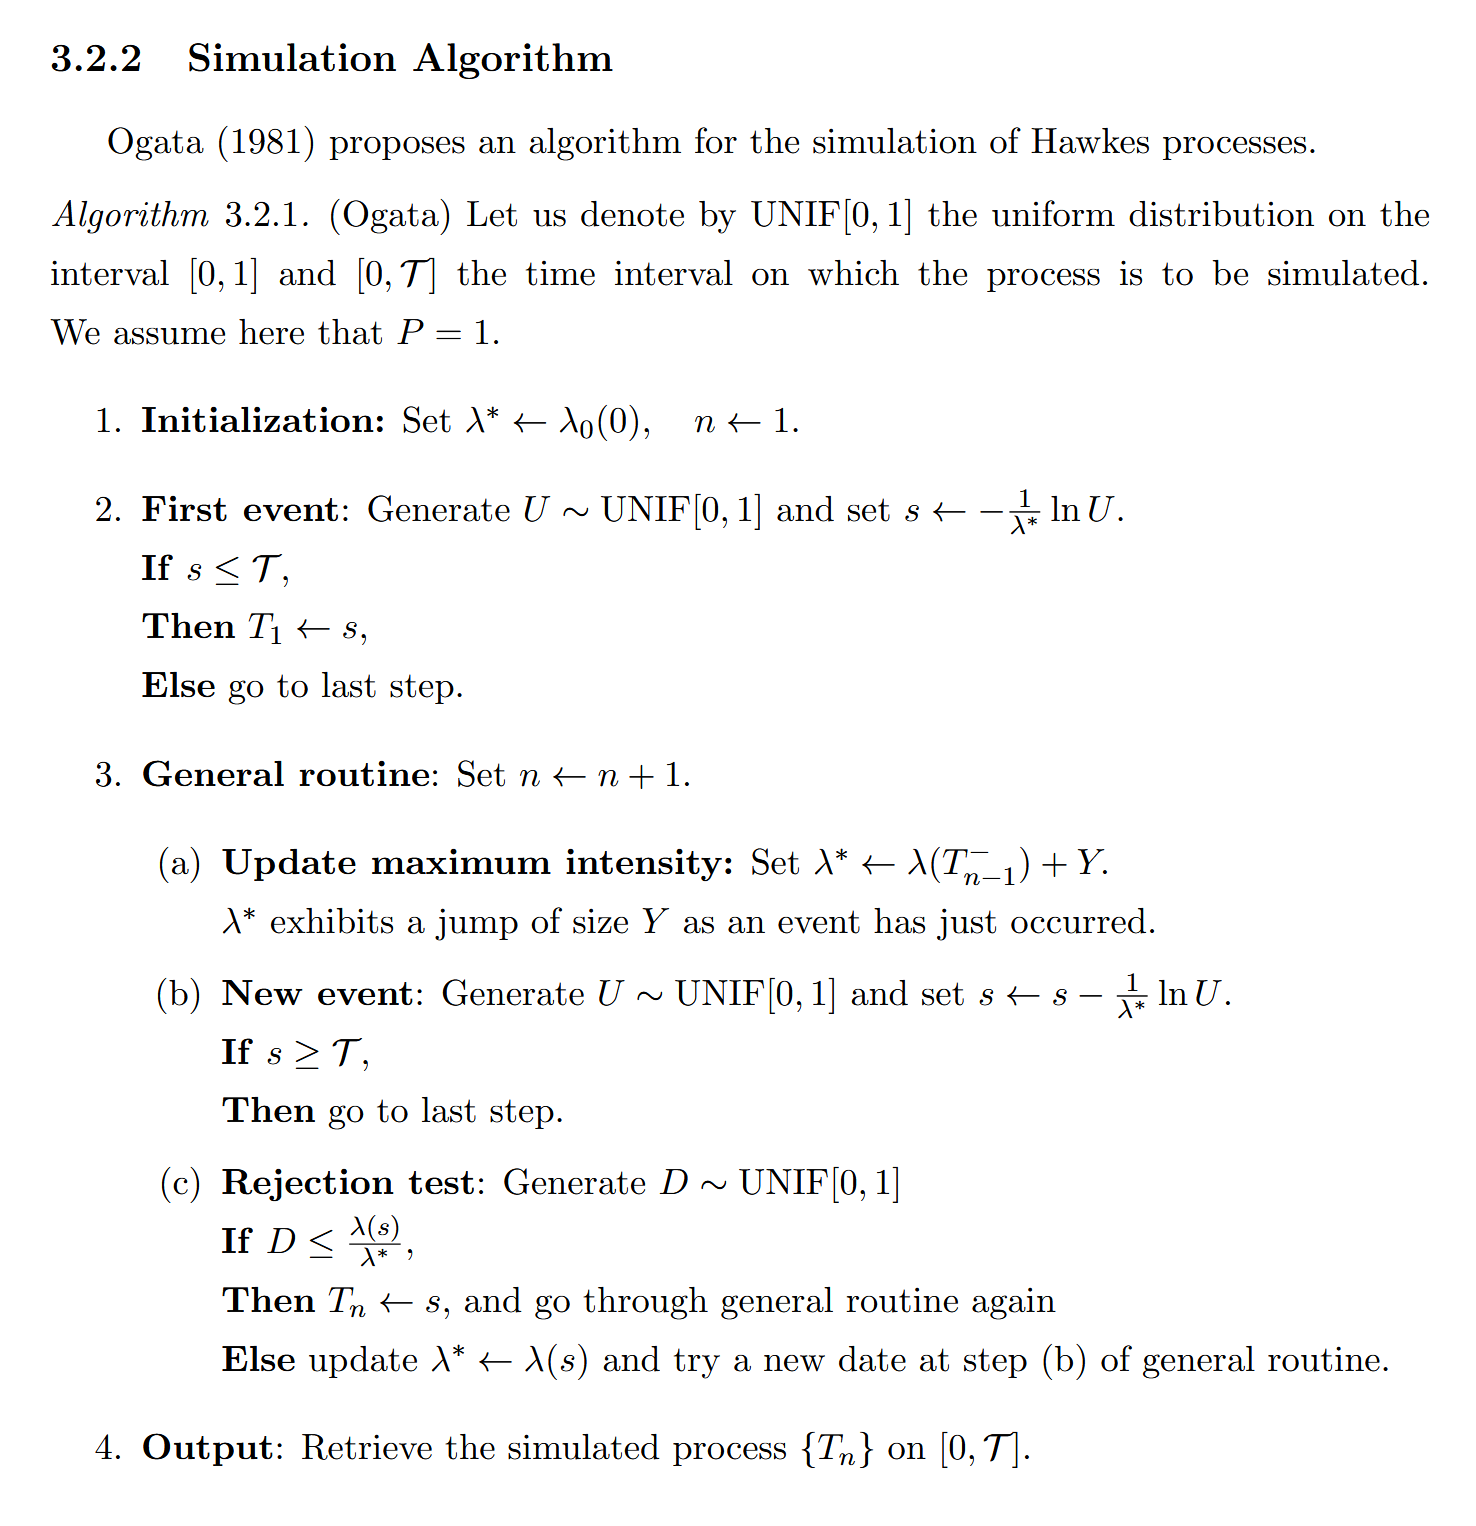

---
## Ogata's thinning algorithm

The simulation follows Algorithm 3.2.1 of Obral (2016), which presents the intensity-based simulation of Hawkes processes due to Ogata (1981). The upper bound on the intensity is denoted `lambda_star` in the code, corresponding to $\lambda^*$ in the algorithm. The candidate time is denoted `t`, corresponding to $s$, and accepted event times are stored
in `events`, corresponding to $\{T_n\}$.

**Initialization:** $\lambda^* \leftarrow \lambda_0(0) = \mu$ and $n \leftarrow 1$.

Before any events have occurred, $\lambda^*(0) = \mu$, so the initial upper bound is the baseline rate.

**First candidate:** $s \leftarrow -\frac{1}{\lambda^*} \ln U$ where $U \sim \text{UNIF}[0,1]$. If $s \leq \mathcal{T}$ then $T_1 \leftarrow s$, otherwise stop.

This generates an exponential random variable with rate $\lambda^*$: if $U \sim \text{UNIF}[0,1]$ then $-\frac{1}{\lambda^*} \ln U \sim \text{Exp}(\lambda^*)$.

**General routine:** Set $n \leftarrow n + 1$.

**Upper bound update after acceptance:** $\lambda^* \leftarrow \lambda(T^-_{n-1}) + Y = \lambda(T_{n-1}) + Y$ where $Y = \alpha$.

After accepting an event at $T_{n-1}$, the intensity jumps by $\alpha$.
The new upper bound $\lambda(T^-_{n-1}) + \alpha =\lambda(T_{n-1}) + \alpha  = \lambda^*(T^+_{n-1})$ is an upper bound on the intensity going forward since between jumps $\lambda^*$ only decays.

**New candidate:** $s \leftarrow s - \frac{1}{\lambda^*} \ln U$ where $U \sim \text{UNIF}[0,1]$. If $s \geq \mathcal{T}$, stop.

**Acceptance condition:** $D \leq \frac{\lambda(s)}{\lambda^*}$ where $D \sim \text{UNIF}[0,1]$.

This is the thinning step: the candidate is accepted with probability
proportional to the true intensity divided by the upper bound. If accepted, set $T_n \leftarrow s$ and return to the general routine.

**Rejection:** tighten the bound to $\lambda^* \leftarrow \lambda(s)$.

After rejection we know $\lambda(s) < \lambda^*$, so $\lambda(s)$ itself serves as a tighter upper bound. Generate a new candidate from the general routine.

**Output:** $\{T_n\}$ on $[0, \mathcal{T}]$.

---

**Recursive evaluation of $\lambda(s)$**

Rather than computing $\mu + \sum_{t_i < s} \alpha e^{-\beta(s-t_i)}$ at each candidate time, the code uses the recursive identity from the proof of Proposition 3. In that proof, the decomposition gives:

$$\lambda^*(t + u) = \mu(1 - e^{-\beta u}) + e^{-\beta u}\lambda^*(t) + \int_{(0,u)} \alpha e^{-\beta(u-v)}\, d\tilde{N}(v)$$

Apply this between two consecutive event times $T_{n-1}$ and $T_n$,
setting $t = T_{n-1}$ and $u = T_n - T_{n-1}$. Since there are no events in the open interval $(T_{n-1}, T_n)$ by definition of consecutive event times, the integral term
$\int_{(0,u)} \alpha e^{-\beta(u-v)} d\tilde{N}(v) = 0$. The formula reduces to:

$$\lambda^*(T_n) = \mu(1 - e^{-\beta(T_n - T_{n-1})}) +
e^{-\beta(T_n - T_{n-1})}\lambda^*(T_{n-1})=\lambda^*(T_n) = \mu + e^{-\beta(T_n - T_{n-1})}(\lambda^*(T_{n-1})
- \mu)$$

---

## Reason behind using this algorithm

The theoretical results established above, particularly Proposition 3 and Proposition 4, prove that for the exponential kernel, the conditional intensity $λ^*(t)$ and the pair $(N(t), λ^*(t))$ are both Markov processes. This has a direct consequence for simulation. Since the future of the process is determined entirely by the current value of $λ^*(t)$, there is no need to store or revisit the full history of past event times at each step. Ogata's thinning algorithm exploits this structure directly.

Since $λ^*(t)$
is left continuous with right limits (as established in Definition 7), and since each event causes an upward jump of size α followed by exponential decay at rate β, we can always find an upper bound $λ^* \ge λ^*(t)$
over any future interval. A homogeneous Poisson process with rate $λ^*$
is trivial to simulate where inter-arrival times are simply iid Exponential$(λ^*)$. We then thin the candidates from this dominating process by accepting each one with probability
$λ(t)/λ^*$, and the accepted points have exactly the correct distribution of the Hawkes process.

---

### The Exponential Kernel

For a general kernel $\phi$, computing $\lambda^*(t)$ at any candidate time requires summing
over all past events, making each step $O(n)$ in the number of events so far. Over a full
simulation this compounds quickly as $n$ grows.

The exponential kernel $\phi(t) = \alpha e^{-\beta t}$ avoids this through the recursive
structure established in the proof of Proposition 3:

$$\lambda^*(t + u) = \mu(1 - e^{-\beta u}) + e^{-\beta u}\lambda^*(t) +
\int_{(0,u)} \alpha e^{-\beta(u-v)}\, d\tilde{N}(v)$$

Between two consecutive events $T_{n-1}$ and $T_n$, no events occur in the open interval
$(T_{n-1}, T_n)$, so the integral term vanishes and the formula reduces to

$$\lambda^*(T_n) = \mu + e^{-\beta(T_n - T_{n-1})}(\lambda^*(T_{n-1}) - \mu)$$

This means updating $\lambda^*$ at each new event only requires knowing the previous value
$\lambda^*(T_{n-1})$ and the elapsed time $T_n - T_{n-1}$, making each step $O(1)$ rather
than $O(n)$. The total cost over $n$ events is therefore $O(n)$, but crucially this is $O(n)$
from doing $n$ steps of $O(1)$ work each, not from repeatedly scanning the full event history.

---

### Structure of the Code

The simulation is organised into four functions:

- `simulate_hawkes`: implements Ogata's thinning algorithm and returns the array of accepted event times in [0, T].
- `compute_lambda_values`:uses the recursive formula to compute $λ^*(T_n^-$) and $λ^*(T_n^+$) at each event time for plotting.
- `intensity_path`:evaluates $λ^*(t)$ on a fine time grid for smooth visualisation.
- `plot_hawkes`: produces the three-panel figure showing $N(t), λ^*(t)$, and the event times $\{T_n\}$.

Two simulations are then run and compared:
1. **$α = 0.0$:** reduces to a homogeneous Poisson process, serving as a baseline.
2. **$α = 0.4$:** activates self-excitation, producing the clustered behaviour characteristic of the Hawkes process.

A Monte Carlo convergence experiment with $M = 5000$ paths numerically verifies that $\mathbb{E}[\lambda^*(t)]$
converges to the theoretical stationary mean $μβ/(β−α)$, providing a direct empirical confirmation of the Markov structure proved above.

## Simulation code

In [ ]:
# Required libraries/packages

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
# Ogata's thinning algorithm
def simulate_hawkes(mu: float, alpha: float, beta: float, T: float,
                    rng: np.random.Generator) -> np.ndarray:
    """
    Return sorted array of event times in [0, T] using Ogata's thinning.

    At each step:
  1.Propose the next candidate time from Poisson with parameter lambda*, where lambda* is an upper bound on the intensity over the next interval.
  2.Accept with probability lambda(t)/lambda*. Otherwise reject i.e., thin.
    """
    events = []
    t = 0.0
    t_prev = 0.0
    lambda_star = mu # upper bound starts at baseline

    while t < T:
        # draw inter-arrival time from the dominating Poisson process
        t += rng.exponential(1.0 / lambda_star)
        if t > T:
            break

        # evaluate true intensity recursively in O(1)
        lambda_t = mu + (lambda_star - mu) * np.exp(-beta * (t - t_prev))

        # thinning accept/reject
        if rng.uniform() <= lambda_t / lambda_star:
            events.append(t)
            lambda_star = lambda_t + alpha  # update bound after acceptance
        else:
            lambda_star = lambda_t  # tighten bound after rejection

        t_prev = t  # update ALWAYS, after both acceptance and rejection

    return np.array(events)

In [ ]:
#  Intensity computation (recursive O(n) with O(1) per event, exact for exponential kernel)
def compute_lambda_values(events: np.ndarray, mu: float,
                           alpha: float, beta: float):
    """
    For each event T_n return:
    lambda_at[n] — left continuous value
    lambda_right[n] — right limit

    Uses the recursive identity:
    lambda(T_n) = mu + (lambda(T_{n-1}^+) − mu) · exp(−beta·(T_n− T_{n-1}))
    lambda(T_n^+) = lambda(T_n) + alpha
    """
    lambda_at    = np.empty(len(events))
    lambda_right = np.empty(len(events))
    prev_right = mu
    prev_t     = 0.0

    for i, t in enumerate(events):
        la = mu + (prev_right - mu) * np.exp(-beta * (t - prev_t))
        lambda_at[i]    = la
        lambda_right[i] = la + alpha
        prev_right = la + alpha
        prev_t     = t

    return lambda_at, lambda_right

In [ ]:
def intensity_path(events: np.ndarray, mu: float, alpha: float, beta: float,
                   T: float, n_pts: int = 2000) -> tuple:
    """
    Sample lambda(t) on a fine grid for plotting the continuous path. Use the same recursive formula for efficiency.
    """
    ts = np.linspace(0, T, n_pts)
    ls = np.full(n_pts, mu, dtype=float)

    for ti in events:
        mask = ts > ti # strict inequality implies left continuous
        ls[mask] += alpha * np.exp(-beta * (ts[mask] - ti))

    return ts, ls

In [ ]:
# Plot
PURPLE = "#534AB7"
TEAL   = "#0F6E56"
GRID_C = "#e8e8e8"
BASE_C = "#aaaaaa"


def plot_hawkes(events: np.ndarray, mu: float, alpha: float,
                beta: float, T: float) -> plt.Figure:

    lambda_at, lambda_right = compute_lambda_values(events, mu, alpha, beta)
    ts, ls = intensity_path(events, mu, alpha, beta, T)
    N = len(events)

    fig, axes = plt.subplots(
        3, 1, figsize=(11, 8),
        gridspec_kw={"height_ratios": [3, 3, 1.2]},
        sharex=True,
    )
    fig.patch.set_facecolor("white")
    fig.suptitle(
        rf"Hawkes Process with Exponential Kernel"
        rf"  |  $\mu={mu}$,  $\alpha={alpha}$,  $\beta={beta}$,"
        rf"  $\alpha/\beta={alpha/beta:.2f}$,  $N(T)={N}$",
        fontsize=11, y=0.99, va="top",
    )

    r_dot = 4.5 # marker radius in points

    #Panel 1: N(t)
    ax1 = axes[0]

    # Build step-function data: right-continuous staircase
    # post_x / post_y give the values just *after* each jump
    step_x = np.concatenate([[0], np.repeat(events, 2), [T]])
    step_y = np.concatenate([[0], np.repeat(np.arange(1, N + 1), 2)])

    # interleave: for each event at t, we go  (t, n-1) then (t, n) then (next_t, n)
    sx, sy = [0.0], [0.0]
    for i, t in enumerate(events):
        sx += [t, t]
        sy += [i, i + 1]
    sx.append(T)
    sy.append(N)

    ax1.plot(sx, sy, color=PURPLE, lw=1.75, solid_capstyle="butt")

    for i, t in enumerate(events):
        # open  circle at N(T_n) = n − 1  (left limit, not attained)
        ax1.plot(t, i,     "o", ms=r_dot, mec=PURPLE, mfc="white", mew=1.5)
        # filled circle at N(T_n)  = n  (right continuous value)
        ax1.plot(t, i + 1, "o", ms=r_dot, color=PURPLE)

    ax1.set_ylabel("N(t)", fontsize=11)
    ax1.set_ylim(-0.5, max(N, 1) + 0.8)
    ax1.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))
    ax1.grid(axis="y", color=GRID_C, lw=0.5)
    ax1.set_facecolor("white")
    ax1.spines[["top", "right"]].set_visible(False)
    ax1.text(0.01, 0.93, "right continuous  (cadlag)",
             transform=ax1.transAxes, fontsize=8.5,
             color="#666", va="top")

    # Panel 2: lambda(t)
    ax2 = axes[1]

    # baseline \mu
    ax2.axhline(mu, color=BASE_C, lw=1, ls="--", label=rf'$\mu = {mu}$')

    # continuous path (left continuous: uses strict inequality in intensity_path)
    ax2.plot(ts, ls, color=TEAL, lw=1.75, label=r'$\lambda^*(t)$')

    for i, t in enumerate(events):
        # filled circle at lambda(T_n) — attained left-continuous value
        ax2.plot(t, lambda_at[i],    "o", ms=r_dot, color=TEAL)
        # open circle at lambda(T_n^+) — right limit, not attained
        ax2.plot(t, lambda_right[i], "o", ms=r_dot, mec=TEAL, mfc="white", mew=1.5)

    ax2.set_ylabel(r'$\lambda^*(t)$', fontsize=11)
    lmax = lambda_right.max() if N > 0 else mu
    ax2.set_ylim(-0.05, lmax * 1.15)
    ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax2.grid(axis="y", color=GRID_C, lw=0.5)
    ax2.set_facecolor("white")
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.legend(fontsize=8.5, loc="upper right", framealpha=0.6)
    ax2.text(0.01, 0.93, "left continuous  (caglad)",
             transform=ax2.transAxes, fontsize=8.5,
             color="#666", va="top")

    #Panel 3: point process {T_n}
    ax3 = axes[2]
    ax3.set_facecolor("white")
    ax3.spines[["top", "right", "left"]].set_visible(False)
    ax3.set_yticks([])

    for i, t in enumerate(events):
        ax3.axvline(t, color=PURPLE, lw=1.4, ymin=0.15, ymax=0.85)
        ax3.plot(t, 0.5, "o", ms=3, color=PURPLE, transform=ax3.transData,
                 clip_on=False)
        if N <= 25:
            label = f"$T_{{{i+1}}}$"
            ax3.text(t, 0.92, label, ha="center", va="top",
                     fontsize=7.5, color=PURPLE,
                     transform=ax3.get_xaxis_transform())

    ax3.set_ylim(0, 1)
    ax3.set_ylabel("Tn", fontsize=11)
    ax3.set_xlabel("t", fontsize=11)
    ax3.grid(axis="x", color=GRID_C, lw=0.5)

    # Shared legend for open and filled dots
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
               markeredgecolor="gray", ms=5, label="value attained  (filled)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="white",
               markeredgecolor="gray", markeredgewidth=1.2, ms=5,
               label="limit not attained  (open)"),
    ]
    fig.legend(handles=legend_handles, loc="lower center",
               ncol=2, fontsize=8.5, framealpha=0.7,
               bbox_to_anchor=(0.5, -0.01))

    plt.xlim(0, T)
    plt.tight_layout(rect=[0, 0.04, 1, 0.97])
    return fig

## Simulation 1: Poisson Process (α = 0.0)

Simulated 22 events over [0, 50]
Branching ratio  alpha/beta = 0.000 (stable)
Empirical rate = 0.440  (theoretical: mu/(1−alpha/beta) = 0.450)
Saved as hawkes_no_excitation.png


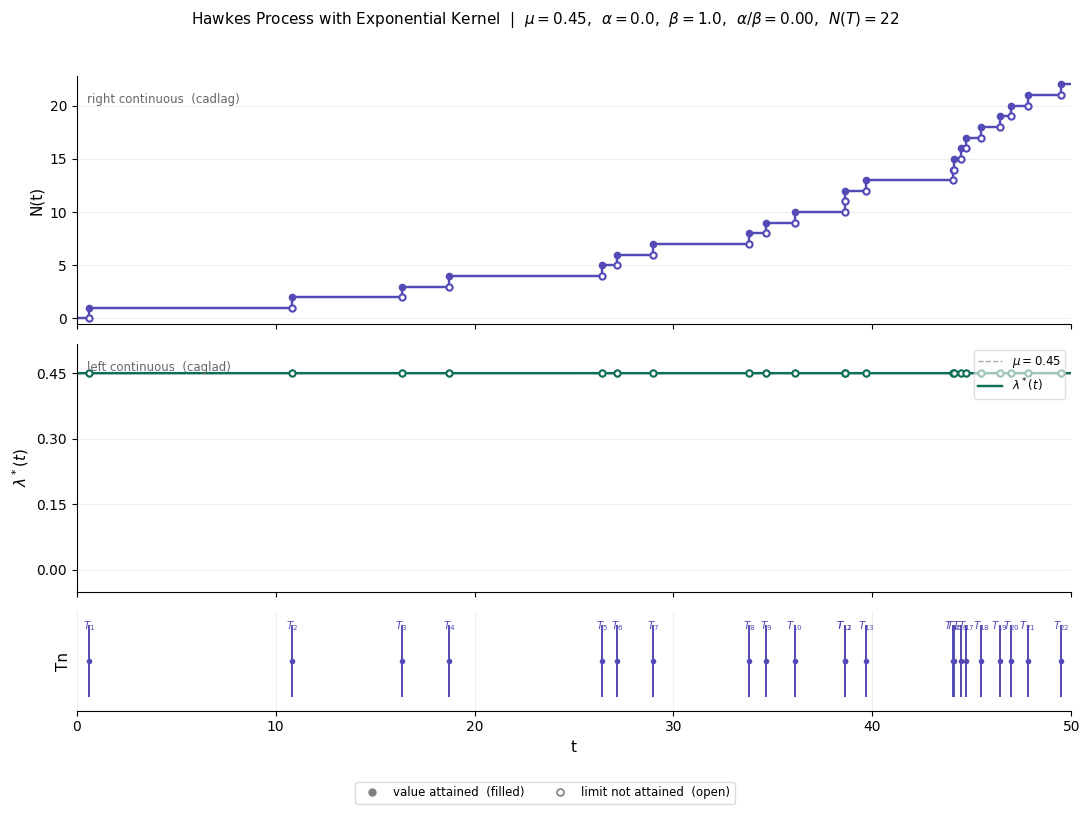

In [ ]:
# Poisson Process with rate mu = 0.45 (alpha = 0.0)


# Parameters
MU    = 0.45   # baseline rate
ALPHA = 0.0   # excitation magnitude
BETA  = 1.0
T     = 50  # time horizon
SEED  = 21    # set to None for a fresh draw each run


rng    = np.random.default_rng(SEED)
events = simulate_hawkes(MU, ALPHA, BETA, T, rng)

print(f"Simulated {len(events)} events over [0, {T}]")
print(f"Branching ratio  alpha/beta = {ALPHA/BETA:.3f} ({'stable' if ALPHA/BETA < 1 else 'UNSTABLE'})")
print(f"Empirical rate = {len(events)/T:.3f}  (theoretical: mu/(1−alpha/beta) = {MU/(1-ALPHA/BETA):.3f})")

fig = plot_hawkes(events, MU, ALPHA, BETA, T)
plt.savefig("hawkes_exponential.png", dpi=150, bbox_inches="tight")
print("Saved as hawkes_no_excitation.png")
plt.show()



Setting α = 0.0 reduces the Hawkes process of Definition 7 to a homogeneous Poisson process with constant intensity λ*(t) = μ = 0.45. There is no excitation term since φ ≡ 0.

**N(t):** The counting process grows at a roughly constant rate
across [0, 50]. The increments show no clustering. Over this interval N(T) = 22 events were recorded, giving an empirical rate of 22/50 = 0.44 which is close to the theoretical rate μ = 0.45. The right-continuous sample path with open circles at each jump time reflects the càdlàg property of N(t) established in Definition 2.

**$\lambda^*(t)$:** The conditional intensity is flat at μ = 0.45 throughout.

**{$T_n$}** are the arrival times spread across [0, 50]. The inter-arrival times $T_{n+1} - T_n$ are independent and exponentially distributed with mean $1/\mu$.

This simulation serves as a reference case. The self-exciting behaviour of the Hawkes process is absent, and the process reduces to a trivial poisson process.

## Simulation 2: Hawkes Process (α = 0.4)

Simulated 33 events over [0, 50]
Branching ratio  alpha/beta = 0.400 (stable)
Empirical rate = 0.660 (theoretical: mu/(1−alpha/beta) = 0.750)
Saved as hawkes_with_excitation.png


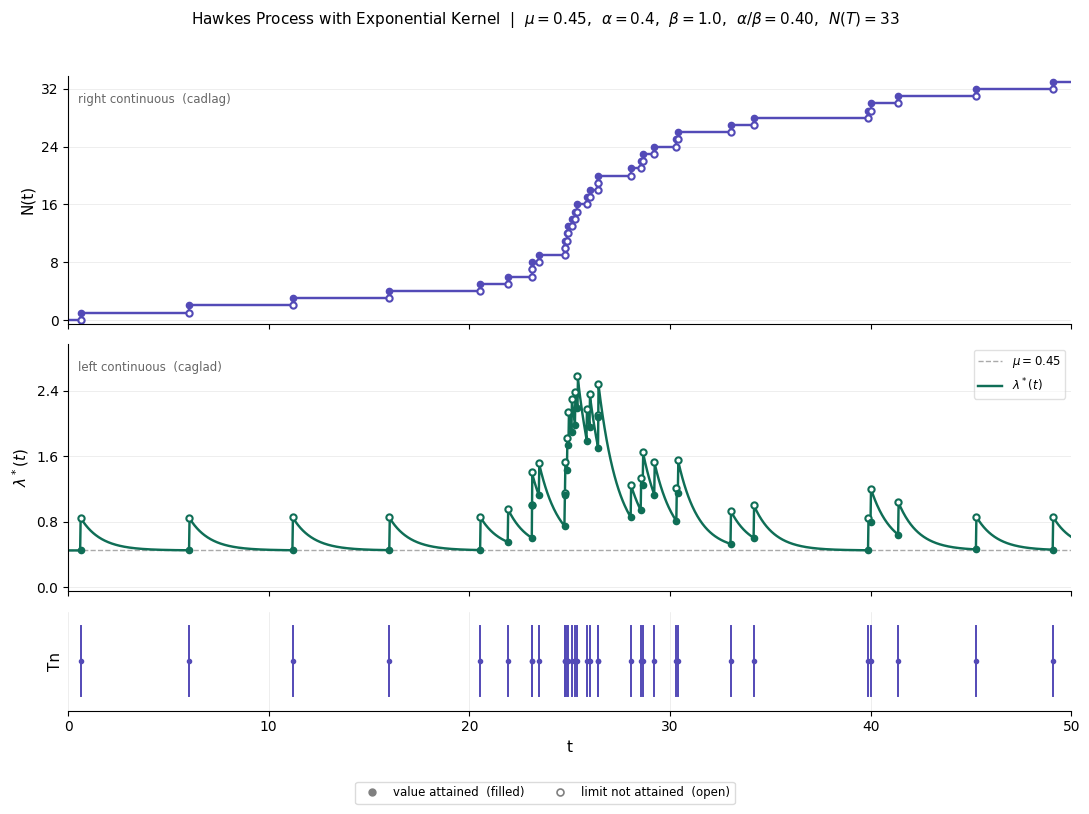

In [ ]:
# HAWKES PROCESS
# Parameters
MU    = 0.45   # baseline rate
ALPHA = 0.4   # excitation magnitude
BETA  = 1.0   # decay rate
T     = 50    # time horizon
SEED  = 21    # set to None for a fresh draw each run


rng    = np.random.default_rng(SEED)
events = simulate_hawkes(MU, ALPHA, BETA, T, rng)

print(f"Simulated {len(events)} events over [0, {T}]")
print(f"Branching ratio  alpha/beta = {ALPHA/BETA:.3f} ({'stable' if ALPHA/BETA < 1 else 'UNSTABLE'})")
print(f"Empirical rate = {len(events)/T:.3f} (theoretical: mu/(1−alpha/beta) = {MU/(1-ALPHA/BETA):.3f})")

fig = plot_hawkes(events, MU, ALPHA, BETA, T)
plt.savefig("hawkes_exponential.png", dpi=150, bbox_inches="tight")
print("Saved as hawkes_with_excitation.png")
plt.show()



Setting $α = 0.4$ activates the excitation term in Definition 7, giving the conditional intensity

$$\lambda^*(t) = \mu + \sum_{t_i < t} \alpha e^{-\beta(t-t_i)}$$

with $μ = 0.45, α = 0.4, β = 1.0,$ and branching ratio $α/β = 0.40 < 1$, satisfying the stability condition of Definition 7.

**$N(t)$:** Unlike the Poisson case, the counting process does not grow at a constant rate. Around $t \in [23, 30]$, a burst of arrivals drives $N(t)$ from roughly 0.8 to 2.5 in a short window. Over $[0, 50], N(T) = 33$ events were recorded. The right-continuous staircase with open circles at each jump reflects the càdlàg property of $N(t)$ from Definition 2.

**$λ^*(t)$:** Per Definition 7, $\lambda^*$ is left-continuous with right limits. At each event time $T_n$, the filled dot marks the attained value $\lambda^*(T_n)$, and the open dot marks the right limit $\lambda^*(T_n^+) = \lambda^*(T_n) + \alpha$. Between events the intensity decays exponentially at rate $β$ back toward $μ$. Around $t \in [23, 30]$, events arrive fast enough that the intensity never fully decays, producing the spikes in the panel with a peak of around 2.5. After the burst it gradually settles back toward the baseline $μ = 0.45$ shown as the dashed line.

**$\{T_n\}$:** The event times cluster heavily around $t \in [23, 30]$ and are sparse elsewhere. This is self-excitation in action i.e., each arrival raises $\lambda^*(t)$, making further arrivals more likely in the short term, exactly as described in Definition 7.

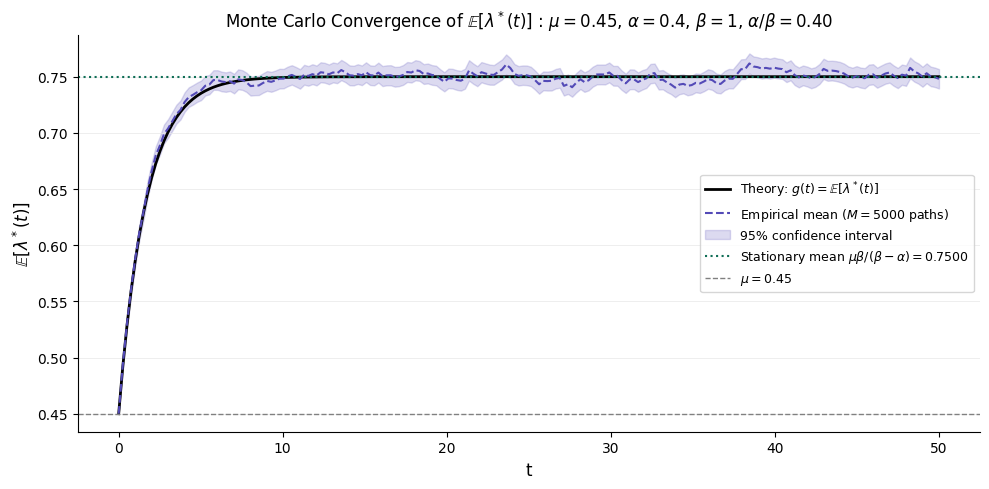

In [ ]:
# Parameters
mu, alpha, beta =  0.45, 0.4, 1
T = 50.0
M = 5000
rng = np.random.default_rng(42)

#Theoretical stationary mean
lambda_bar = mu * beta / (beta - alpha)

#Time grid
t_grid = np.linspace(0, T, 200)

#Theoretical formula
g_theory = lambda_bar - (mu * alpha / (beta - alpha)) * np.exp(-(beta - alpha) * t_grid)

#Simulate M paths and collect lambda*(t) at each grid point
lambda_samples = np.zeros((M, len(t_grid)))

for m in range(M):
    events = simulate_hawkes(mu, alpha, beta, T, rng)
    #Use intensity_path to get lambda* on the grid
    ts, ls = intensity_path(events, mu, alpha, beta, T, n_pts=len(t_grid))
    lambda_samples[m, :] = ls

#Empirical mean and confidence interval
g_empirical = np.mean(lambda_samples, axis=0)
g_std = np.std(lambda_samples, axis=0)
ci_lower = g_empirical - 1.96 * g_std / np.sqrt(M)
ci_upper = g_empirical + 1.96 * g_std / np.sqrt(M)

#Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_grid, g_theory, 'k-', lw=2, label=r'Theory: $g(t) = \mathbb{E}[\lambda^*(t)]$')
ax.plot(t_grid, g_empirical, '--', color='#534AB7', lw=1.5,
        label=rf'Empirical mean ($M={M}$ paths)')
ax.fill_between(t_grid, ci_lower, ci_upper, alpha=0.2, color='#534AB7',
                label='95% confidence interval')
ax.axhline(lambda_bar, color='#0F6E56', ls=':', lw=1.5,
           label=rf'Stationary mean $\mu\beta/(\beta-\alpha) = {lambda_bar:.4f}$')
ax.axhline(mu, color='gray', ls='--', lw=1, label=rf'$\mu = {mu}$')

ax.set_xlabel('t', fontsize=12)
ax.set_ylabel(r'$\mathbb{E}[\lambda^*(t)]$', fontsize=12)
ax.set_title(rf'Monte Carlo Convergence of $\mathbb{{E}}[\lambda^*(t)] $ : '
             rf'$\mu={mu}$, $\alpha={alpha}$, $\beta={beta}$, '
             rf'$\alpha/\beta={alpha/beta:.2f}$',
             fontsize=12)
ax.legend(fontsize=9, loc='right')
ax.set_facecolor('white')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#e8e8e8', lw=0.5)
plt.tight_layout()
plt.show()

 **Interpretation: Monte Carlo Convergence of $\mathbb{E}[\lambda^*(t)]$**

For each of the $M = 5000$ simulated paths, $\lambda^*(t)$ is evaluated on a fine time grid
over $[0, 50]$ and compared against the theoretical formula

$$g(t) = \mathbb{E}[\lambda^*(t)] = \frac{\mu\beta}{\beta - \alpha} -
\frac{\mu\alpha}{\beta - \alpha} e^{-(\beta - \alpha)t}$$

**Theoretical curve $g(t)$ (solid black):** Starts at $\mu = 0.45$ at $t = 0$ and
converges to $\mu\beta/(\beta - \alpha) = 0.75$. The curve rises steeply at first and
flattens out.

**Empirical mean (dashed blue):** Tracks $g(t)$ closely throughout $[0, 50]$, with
convergence to the stationary mean visible by around $t = 10$.

**95% confidence interval (shaded blue):** Constant around theoretical value as $t$ increases, as variability between
paths reduces once the process is stationary.

**Stationary mean $\mu\beta/(\beta - \alpha) = 0.75$ (dotted green):** Both $g(t)$ and the
empirical mean converge to this value, consistent with the stability condition $\alpha/\beta
= 0.40 < 1$ of Definition 7.

The convergence of the empirical mean to $g(t)$ numerically validates the theoretical results in Proposition 6.